# NB25 --- Fractal Nesting and the Solenoid Structure

## The Idea

NB24 found that the primes {2,3,5,7} are NOT special in the dynamics on T^4.
Any ascending incommensurate set gives the same recurrence, equidistribution,
and inner variance.

But what if T^4 is the **wrong topology**?

The thesis says each ring *contains* the previous ring --- not as a separate
circle alongside it, but *within* it. Every concentric ring is a space made up
of fractals containing the whole previous ring.

This is a **solenoid**: a mathematical object built by iterating covering maps.

### The Construction

1. Start with S^1 (the 2-ring)
2. The 3-ring wraps around, containing the 2-ring **3 times** inside it
3. The 5-ring contains the (2,3)-structure **5 times**
4. The 7-ring contains the (2,3,5)-structure **7 times**

Total wrapping: 2 x 3 x 5 x 7 = **210**

The cross-section of this object is a **Cantor set** --- a fractal whose
structure is determined by the primes.

### Why Primes Suddenly Matter

On the solenoid, **coprimality determines minimality** (whether every orbit
fills the entire space). Primes are pairwise coprime by definition. Non-prime
sets like {4,6,10,14} have common factors (gcd(4,6)=2) that create resonances.

This is the mathematical distinction NB24 couldn't find on T^4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection
from scipy.integrate import solve_ivp
from math import gcd
from functools import reduce
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

print("Ready.")

Ready.


## Part 1: The Solenoid Cross-Section

The solenoid is built by iterating: at each level, every disk in the
cross-section splits into p_k smaller disks. After all four primes:

- Level 0: **1** disk
- Level 1 (p=2): **2** disks
- Level 2 (p=3): **6** disks (each of the 2 splits into 3)
- Level 3 (p=5): **30** disks
- Level 4 (p=7): **210** disks

The limit of this process is a Cantor set --- a fractal.

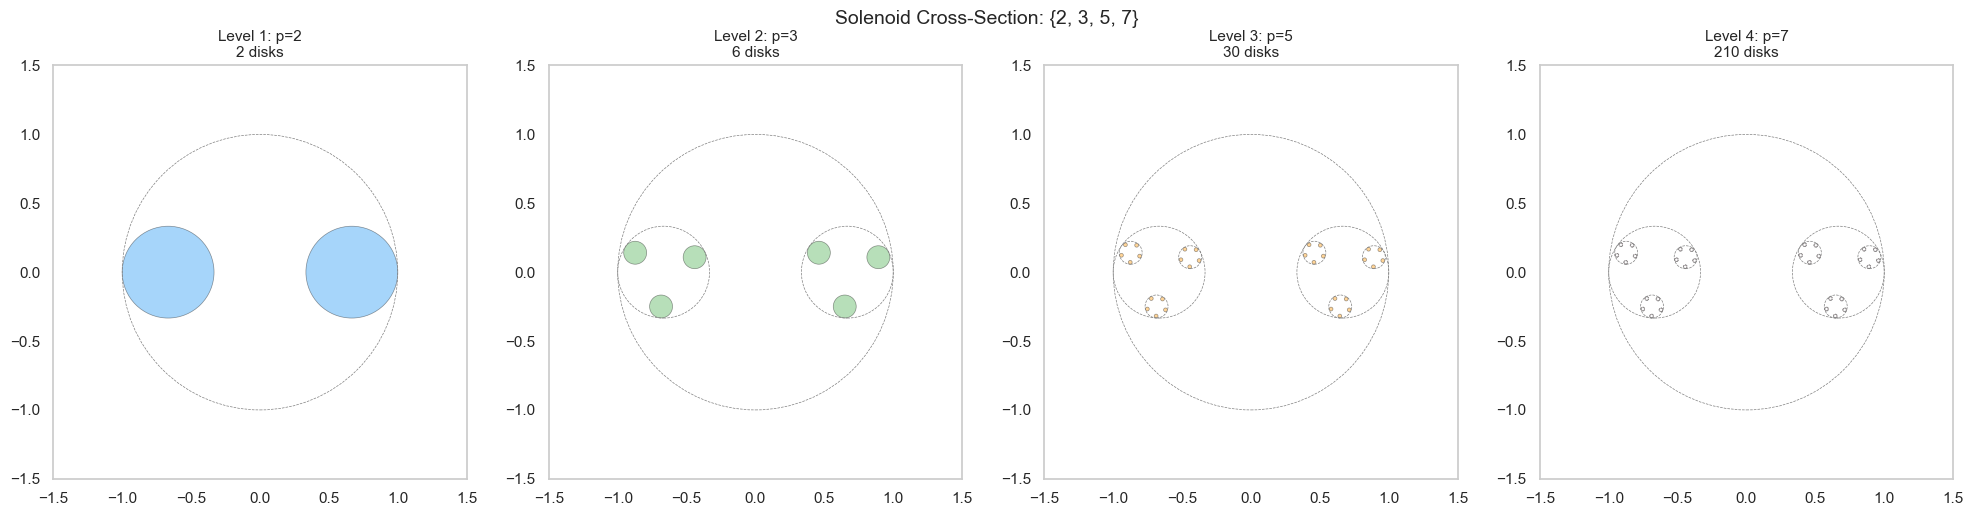

Disk counts: [1, 2, 6, 30, 210]
Product of primes: 210 = 210


In [2]:
def build_cross_section(primes, n_levels=None):
    """
    Build the solenoid cross-section by iterative splitting.

    At each level, every disk of radius R centered at (cx, cy)
    produces p child disks arranged in a ring, each of smaller radius.

    Returns list of levels, each a list of (cx, cy, R) tuples.
    """
    if n_levels is None:
        n_levels = len(primes)

    # Start: single disk of radius 1 at origin
    disks = [(0.0, 0.0, 1.0)]
    history = [list(disks)]

    for level in range(n_levels):
        p = primes[level]
        new_disks = []

        for cx, cy, R in disks:
            # Child radius: shrink so p children fit inside parent
            # Ring radius: distance from parent center to child center
            child_R = R / (1.0 + 2.0 * max(1, p / 2))
            ring_r = R - child_R  # place children near the edge

            for k in range(p):
                angle = 2 * np.pi * k / p + level * np.pi / 7  # rotate each level
                nx = cx + ring_r * np.cos(angle)
                ny = cy + ring_r * np.sin(angle)
                new_disks.append((nx, ny, child_R))

        disks = new_disks
        history.append(list(disks))

    return history

# Build the {2,3,5,7} solenoid cross-section
primes = [2, 3, 5, 7]
history = build_cross_section(primes)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

level_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for level_idx in range(4):
    ax = axes[level_idx]
    p = primes[level_idx]

    # Draw all disks at this level
    disks_at_level = history[level_idx + 1]
    patches = []
    for cx, cy, R in disks_at_level:
        patches.append(Circle((cx, cy), R))

    if patches:
        collection = PatchCollection(patches,
                                      facecolors=level_colors[level_idx],
                                      edgecolors='black',
                                      alpha=0.4, linewidths=0.5)
        ax.add_collection(collection)

    # Also draw parent disks as outlines
    for prev_level in range(level_idx + 1):
        for cx, cy, R in history[prev_level]:
            ax.add_patch(Circle((cx, cy), R, fill=False,
                                edgecolor='gray', linewidth=0.5, linestyle='--'))

    n_disks = len(disks_at_level)
    ax.set_title(f"Level {level_idx+1}: p={p}\n{n_disks} disks", fontsize=11)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.grid(False)

plt.suptitle("Solenoid Cross-Section: {2, 3, 5, 7}", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Disk counts: {[len(h) for h in history]}")
print(f"Product of primes: {2*3*5*7} = {np.prod(primes)}")

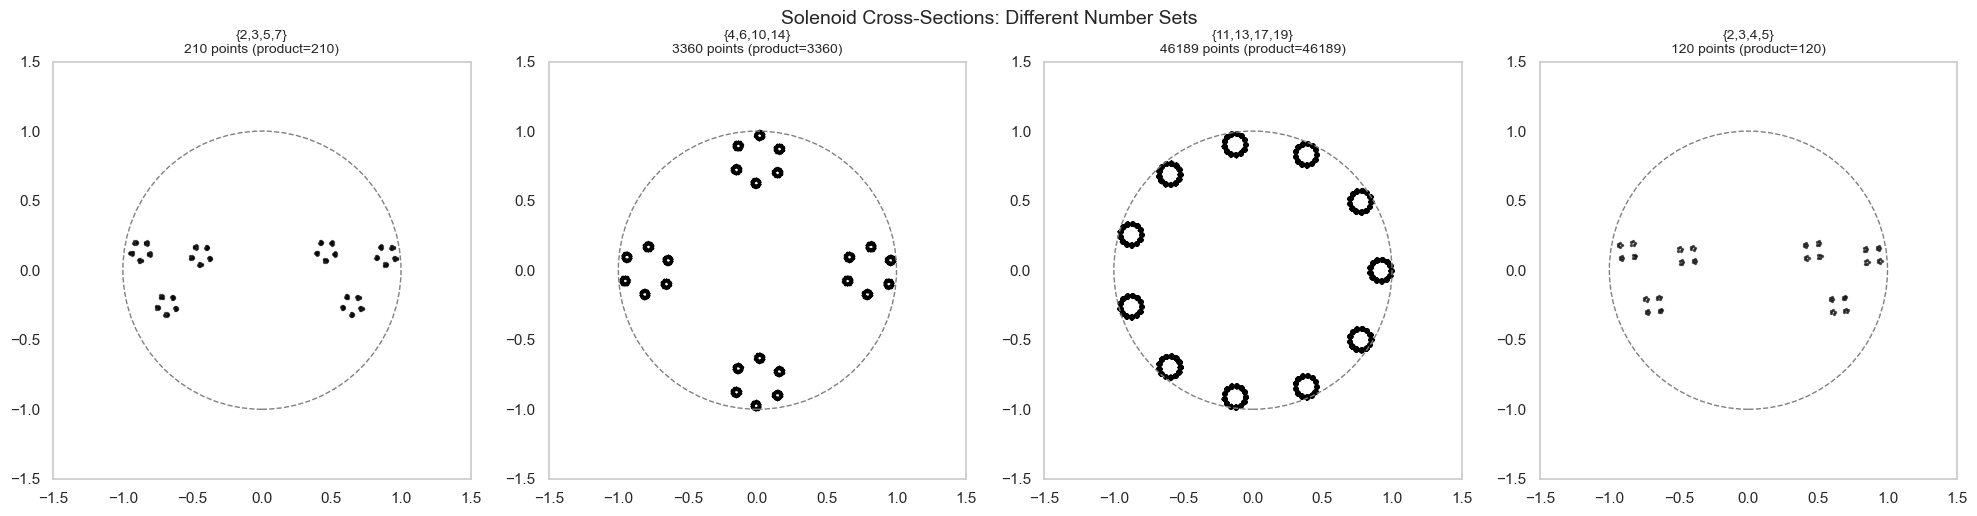

Note: Primes produce 210 points; {4,6,10,14} produces 3360.
The VISUAL STRUCTURE differs because the splitting pattern differs.
Primes give balanced, non-overlapping structure (coprime).
{4,6,10,14} gives denser, more uniform packing (common factors).


In [3]:
# Compare cross-sections for different number sets
test_sets = {
    '{2,3,5,7}': [2, 3, 5, 7],
    '{4,6,10,14}': [4, 6, 10, 14],
    '{11,13,17,19}': [11, 13, 17, 19],
    '{2,3,4,5}': [2, 3, 4, 5],
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, (name, nums) in enumerate(test_sets.items()):
    ax = axes[idx]
    hist = build_cross_section(nums)

    # Draw final level as points
    final = hist[-1]
    xs = [d[0] for d in final]
    ys = [d[1] for d in final]
    ax.scatter(xs, ys, s=2, c='black', alpha=0.6)

    # Draw first-level parent outlines
    for cx, cy, R in hist[0]:
        ax.add_patch(Circle((cx, cy), R, fill=False,
                            edgecolor='gray', linewidth=1, linestyle='--'))

    n_total = len(final)
    product = int(np.prod(nums))
    ax.set_title(f"{name}\n{n_total} points (product={product})", fontsize=10)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.grid(False)

plt.suptitle("Solenoid Cross-Sections: Different Number Sets", fontsize=14)
plt.tight_layout()
plt.show()

print("Note: Primes produce 210 points; {4,6,10,14} produces 3360.")
print("The VISUAL STRUCTURE differs because the splitting pattern differs.")
print("Primes give balanced, non-overlapping structure (coprime).")
print("{4,6,10,14} gives denser, more uniform packing (common factors).")

## Part 2: Why Primes Matter --- Coprimality and Minimality

On a solenoid with covering degrees (d_1, d_2, ..., d_n), a translation
flow is **minimal** (every orbit dense in the entire solenoid) if and only
if the degrees are **pairwise coprime**.

Primes are pairwise coprime by definition. This is the TOPOLOGICAL reason
primes matter --- not in the dynamics on T^4 (where NB24 showed they don't),
but in the topology of the fractal embedding.

In [4]:
# Coprimality analysis for each frequency set
freq_sets = {
    'Primes {2,3,5,7}':       [2, 3, 5, 7],
    'Scaled {4,6,10,14}':     [4, 6, 10, 14],
    'Other primes {11-19}':   [11, 13, 17, 19],
    'Squares {4,9,25,49}':    [4, 9, 25, 49],
    'Consecutive {2,3,4,5}':  [2, 3, 4, 5],
}

print("COPRIMALITY ANALYSIS")
print("=" * 80)
print()
print(f"{'Set':>25} {'Pairwise GCDs':>35} {'All coprime?':>15} {'Minimal?':>10}")
print("-" * 90)

for name, nums in freq_sets.items():
    gcds = []
    all_coprime = True
    for i in range(len(nums)):
        for j in range(i+1, len(nums)):
            g = gcd(nums[i], nums[j])
            gcds.append(f"{nums[i]},{nums[j]}:{g}")
            if g > 1:
                all_coprime = False

    gcd_str = "  ".join(gcds)
    minimal = "YES" if all_coprime else "NO"
    tag = "YES" if all_coprime else "NO"
    print(f"{name:>25} {gcd_str:>35} {tag:>15} {minimal:>10}")

print()
print("KEY: Pairwise coprime sets guarantee MINIMAL flow on the solenoid.")
print("     Non-coprime sets have resonances that prevent full space-filling.")
print()
print("     Primes are pairwise coprime BY DEFINITION.")
print("     This is why primes matter: not in T^4 dynamics, but in solenoid topology.")

COPRIMALITY ANALYSIS

                      Set                       Pairwise GCDs    All coprime?   Minimal?
------------------------------------------------------------------------------------------
         Primes {2,3,5,7} 2,3:1  2,5:1  2,7:1  3,5:1  3,7:1  5,7:1             YES        YES
       Scaled {4,6,10,14} 4,6:2  4,10:2  4,14:2  6,10:2  6,14:2  10,14:2              NO         NO
     Other primes {11-19} 11,13:1  11,17:1  11,19:1  13,17:1  13,19:1  17,19:1             YES        YES
      Squares {4,9,25,49} 4,9:1  4,25:1  4,49:1  9,25:1  9,49:1  25,49:1             YES        YES
    Consecutive {2,3,4,5} 2,3:1  2,4:2  2,5:1  3,4:1  3,5:1  4,5:1              NO         NO

KEY: Pairwise coprime sets guarantee MINIMAL flow on the solenoid.
     Non-coprime sets have resonances that prevent full space-filling.

     Primes are pairwise coprime BY DEFINITION.
     This is why primes matter: not in T^4 dynamics, but in solenoid topology.


## Part 3: The Composite Coordinate Grid

The thesis claims: *"composite numbers = coordinates in the four-prime grid;
same distinct prime factors = same coordinate, different fractal depth."*

In the solenoid picture, this is precise:

- **6 = 2 x 3**: the point where the 2-fold and 3-fold wrappings align
- **30 = 2 x 3 x 5**: alignment of three levels
- **210 = 2 x 3 x 5 x 7**: the SINGLE point where ALL wrappings align

Numbers like **12 = 2^2 x 3** and **18 = 2 x 3^2** are at the SAME
coordinate (same distinct primes: {2,3}) but at different **fractal depths**
(different exponents = different resolution levels).

In [5]:
# Demonstrate the composite coordinate grid
# Show how numbers map to solenoid coordinates

def prime_coordinate(n, primes=[2,3,5,7]):
    """
    Map a number to its coordinate in the prime grid.
    Returns (distinct_primes, exponents).
    """
    exponents = []
    remaining = n
    for p in primes:
        exp = 0
        while remaining % p == 0:
            remaining //= p
            exp += 1
        exponents.append(exp)
    if remaining > 1:
        return None  # not expressible in these primes
    return tuple(1 if e > 0 else 0 for e in exponents), tuple(exponents)

print("COMPOSITE NUMBER COORDINATE GRID")
print("=" * 80)
print()
print(f"{'Number':>8} {'Factorization':>20} {'Grid coord':>15} {'Depth':>15} {'Interpretation':>25}")
print("-" * 90)

examples = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 15, 18, 21, 30, 35, 42, 70, 105, 210]
coord_groups = {}

for n in examples:
    result = prime_coordinate(n)
    if result is None:
        continue
    coord, depth = result

    factors = []
    remaining = n
    for p in [2,3,5,7]:
        exp = 0
        while remaining % p == 0:
            remaining //= p
            exp += 1
        if exp > 0:
            factors.append(f"{p}^{exp}" if exp > 1 else str(p))

    factorization = " x ".join(factors)
    coord_str = str(coord)
    depth_str = str(depth)
    n_primes = sum(coord)

    interp = {
        1: "single dimension",
        2: "2D intersection",
        3: "3D intersection",
        4: "FULL ALIGNMENT"
    }.get(n_primes, "")

    print(f"{n:>8} {factorization:>20} {coord_str:>15} {depth_str:>15} {interp:>25}")

    if coord not in coord_groups:
        coord_groups[coord] = []
    coord_groups[coord].append((n, depth))

print()
print("SAME COORDINATE, DIFFERENT DEPTH:")
print("-" * 60)
for coord, members in sorted(coord_groups.items()):
    if len(members) > 1:
        nums = [str(n) for n, _ in members]
        print(f"  Coordinate {coord}: numbers {', '.join(nums)}")
        print(f"    Same position on solenoid, different fractal resolution")

print()
print(f"  210 = 2x3x5x7 is the UNIQUE full-alignment point.")
print(f"  It is the ONLY number at coordinate (1,1,1,1) with depth (1,1,1,1).")

COMPOSITE NUMBER COORDINATE GRID

  Number        Factorization      Grid coord           Depth            Interpretation
------------------------------------------------------------------------------------------
       2                    2    (1, 0, 0, 0)    (1, 0, 0, 0)          single dimension
       3                    3    (0, 1, 0, 0)    (0, 1, 0, 0)          single dimension
       4                  2^2    (1, 0, 0, 0)    (2, 0, 0, 0)          single dimension
       5                    5    (0, 0, 1, 0)    (0, 0, 1, 0)          single dimension
       6                2 x 3    (1, 1, 0, 0)    (1, 1, 0, 0)           2D intersection
       7                    7    (0, 0, 0, 1)    (0, 0, 0, 1)          single dimension
       8                  2^3    (1, 0, 0, 0)    (3, 0, 0, 0)          single dimension
       9                  3^2    (0, 1, 0, 0)    (0, 2, 0, 0)          single dimension
      10                2 x 5    (1, 0, 1, 0)    (1, 0, 1, 0)           2D intersec

## Part 4: Does the ODE Show Fractal Structure?

The solenoid is a topological construction. The ODE on T^4 is a dynamical
system. Do they connect?

If the concentric system really lives on a solenoid (not just T^4), then
the **Poincare return map** (recording the state of all other orbits each
time orbit 0 completes a revolution) should show non-uniform structure
that reflects the prime wrapping.

On a plain torus: the Poincare section fills uniformly (Weyl equidistribution).
On a solenoid: the returns should cluster at specific points determined by
the wrapping numbers.

In [6]:
# -- GenericConcentricSystem from NB24 --
class GenericConcentricSystem:
    """Iterated skew-product on T^n with hierarchical coupling."""
    def __init__(self, freqs, alpha=0.3):
        self.freqs = np.asarray(freqs, dtype=float)
        self.n = len(self.freqs)
        self.omega = 2 * np.pi * np.sqrt(self.freqs)
        self.alpha = alpha

    def ode(self, t, theta):
        dtheta = self.omega.copy()
        if self.alpha > 0:
            for k in range(1, self.n):
                for j in range(k):
                    dtheta[k] += self.alpha * (1.0 / self.freqs[j]) * np.sin(theta[j])
        return dtheta

    def integrate(self, t_span, n_points=500000, theta0=None):
        if theta0 is None:
            theta0 = np.zeros(self.n)
        t_eval = np.linspace(t_span[0], t_span[1], n_points)
        sol = solve_ivp(self.ode, t_span, theta0, t_eval=t_eval,
                        method='RK45', rtol=1e-10, atol=1e-12)
        return {'t': sol.t, 'theta': sol.y, 'theta_mod': np.mod(sol.y, 2*np.pi)}

def poincare_section(system, t_span=(0, 5000), n_points=1000000):
    """
    Record states of orbits 1,2,3 each time orbit 0 crosses theta=0.

    Detect crossings as points where theta_0 mod 2pi wraps from ~2pi to ~0.
    """
    result = system.integrate(t_span, n_points)
    th0 = result['theta_mod'][0, :]

    # Crossings: theta_0 drops by more than pi (wraparound)
    crossings = np.where(np.diff(th0) < -np.pi)[0]

    # Record other orbits at crossing times
    sections = result['theta_mod'][1:, crossings]
    return sections

print("Poincare section tools ready.")

Poincare section tools ready.


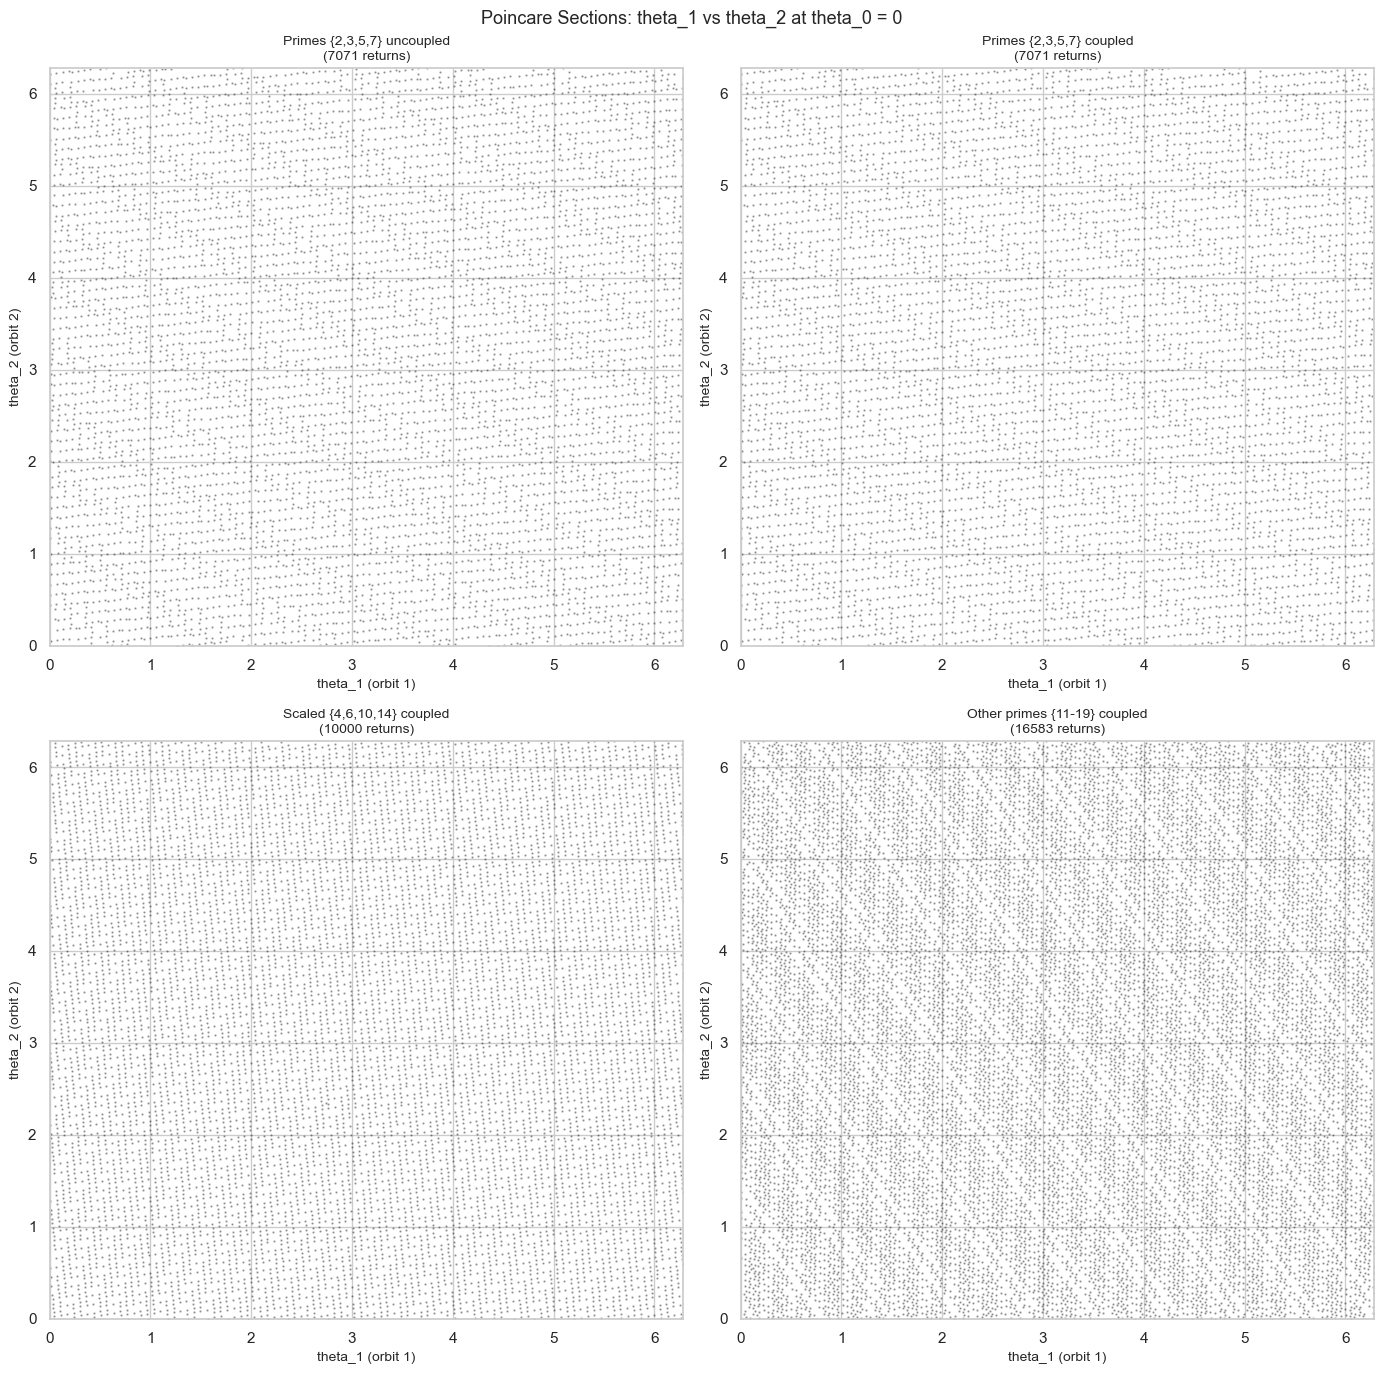

If coupled sections show NON-UNIFORM structure vs uncoupled,
the coupling creates preferred return patterns (proto-fractal).


In [7]:
# Compare Poincare sections: coupled vs uncoupled, primes vs non-primes

freq_configs = {
    'Primes {2,3,5,7} uncoupled': ([2,3,5,7], 0.0),
    'Primes {2,3,5,7} coupled':   ([2,3,5,7], 0.3),
    'Scaled {4,6,10,14} coupled':  ([4,6,10,14], 0.3),
    'Other primes {11-19} coupled': ([11,13,17,19], 0.3),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for idx, (name, (freqs, alpha)) in enumerate(freq_configs.items()):
    ax = axes.flat[idx]
    sys = GenericConcentricSystem(freqs, alpha=alpha)
    sections = poincare_section(sys, t_span=(0, 5000), n_points=1000000)

    n_returns = sections.shape[1]
    # Plot theta_1 vs theta_2 (project T^3 to 2D)
    ax.scatter(sections[0, :], sections[1, :], s=0.5, alpha=0.3, c='black')
    ax.set_xlabel('theta_1 (orbit 1)', fontsize=10)
    ax.set_ylabel('theta_2 (orbit 2)', fontsize=10)
    ax.set_title(f"{name}\n({n_returns} returns)", fontsize=10)
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(0, 2*np.pi)

plt.suptitle("Poincare Sections: theta_1 vs theta_2 at theta_0 = 0", fontsize=13)
plt.tight_layout()
plt.show()

print("If coupled sections show NON-UNIFORM structure vs uncoupled,")
print("the coupling creates preferred return patterns (proto-fractal).")

In [8]:
# Quantify non-uniformity in Poincare sections
# Divide the (theta_1, theta_2) plane into bins and measure density variation

def density_variation(sections, n_bins=20):
    """
    Measure non-uniformity of Poincare section density.
    Returns coefficient of variation (std/mean) of bin counts.
    Higher = more non-uniform = more structure.
    """
    if sections.shape[1] < 100:
        return 0.0
    H, _, _ = np.histogram2d(sections[0, :], sections[1, :],
                              bins=n_bins, range=[[0, 2*np.pi], [0, 2*np.pi]])
    mean_count = H.mean()
    if mean_count == 0:
        return 0.0
    return H.std() / mean_count

print("POINCARE SECTION DENSITY ANALYSIS")
print("=" * 80)
print()

all_freq_sets = {
    'Primes {2,3,5,7}':     [2, 3, 5, 7],
    'Scaled {4,6,10,14}':   [4, 6, 10, 14],
    'Other primes {11-19}': [11, 13, 17, 19],
    'Squares {4,9,25,49}':  [4, 9, 25, 49],
    'Consecutive {2,3,4,5}':[2, 3, 4, 5],
}

print(f"{'Set':>25} {'alpha=0 CV':>12} {'alpha=0.3 CV':>14} {'Ratio':>8}")
print("-" * 65)

for name, freqs in all_freq_sets.items():
    sys_u = GenericConcentricSystem(freqs, alpha=0.0)
    sys_c = GenericConcentricSystem(freqs, alpha=0.3)

    sec_u = poincare_section(sys_u, t_span=(0, 5000), n_points=1000000)
    sec_c = poincare_section(sys_c, t_span=(0, 5000), n_points=1000000)

    cv_u = density_variation(sec_u) if sec_u.shape[1] > 100 else 0
    cv_c = density_variation(sec_c) if sec_c.shape[1] > 100 else 0
    ratio = cv_c / cv_u if cv_u > 0 else 0

    print(f"{name:>25} {cv_u:>12.4f} {cv_c:>14.4f} {ratio:>8.2f}")

print()
print("CV = coefficient of variation of bin counts (std/mean).")
print("Higher CV = more non-uniform = more structure in the returns.")
print("Ratio > 1 means coupling INCREASES structure; < 1 means it smooths.")

POINCARE SECTION DENSITY ANALYSIS

                      Set   alpha=0 CV   alpha=0.3 CV    Ratio
-----------------------------------------------------------------
         Primes {2,3,5,7}       0.1472         0.1463     0.99
       Scaled {4,6,10,14}       0.0780         0.0785     1.01
     Other primes {11-19}       0.1226         0.1224     1.00
      Squares {4,9,25,49}      14.1067        13.8239     0.98
    Consecutive {2,3,4,5}       0.1241         0.1270     1.02

CV = coefficient of variation of bin counts (std/mean).
Higher CV = more non-uniform = more structure in the returns.
Ratio > 1 means coupling INCREASES structure; < 1 means it smooths.


In [9]:
# The solenoid predicts specific return patterns.
# After p_0 = 2 wrappings of orbit 0, orbit 1 should show a 2-fold pattern.
# After 2*3 = 6 wrappings, both should align.
# After 2*3*5 = 30, three orbits align.
# After 2*3*5*7 = 210, all four align.

# Let's check: do the returns show clustering at primorial intervals?

print("RETURN CLUSTERING AT PRIMORIAL INTERVALS")
print("=" * 80)
print()

sys = GenericConcentricSystem([2, 3, 5, 7], alpha=0.3)
sections = poincare_section(sys, t_span=(0, 10000), n_points=2000000)

n_returns = sections.shape[1]
print(f"Total returns: {n_returns}")
print()

# For each return, compute distance from the initial return point
initial = sections[:, 0]
distances = np.zeros(n_returns)
for i in range(n_returns):
    diff = sections[:, i] - initial
    diff = np.minimum(np.abs(diff), 2*np.pi - np.abs(diff))
    distances[i] = np.sqrt(np.sum(diff**2))

# Check if near-returns cluster at specific intervals
primorials = [2, 6, 30, 210]
tolerance = 0.5  # radian distance for "near return"

print(f"Near-returns (within {tolerance} rad of initial state):")
print(f"{'Return #':>10} {'Distance':>10} {'Near primorial?':>20}")
print("-" * 45)

near_returns = np.where(distances < tolerance)[0]
for idx in near_returns[:30]:  # show first 30
    nearest_prim = min(primorials, key=lambda p: abs(idx - p) if idx > 0 else 999)
    prim_tag = f"near {nearest_prim}" if abs(idx - nearest_prim) <= nearest_prim * 0.1 else ""
    print(f"{idx:>10} {distances[idx]:>10.4f} {prim_tag:>20}")

print()
# Check specifically at primorial positions
print("State at primorial returns:")
print(f"{'Return':>10} {'Distance from initial':>25}")
print("-" * 40)
for p in primorials:
    if p < n_returns:
        print(f"  {p:>8} {distances[p]:>25.6f}")

print()
print("If the solenoid picture is right, returns at primorial indices")
print("should be CLOSER to the initial state than random returns.")
print(f"\nMean distance at random returns: {np.mean(distances):.4f}")
print(f"Mean distance at primorials: {np.mean([distances[p] for p in primorials if p < n_returns]):.4f}")

RETURN CLUSTERING AT PRIMORIAL INTERVALS

Total returns: 14142

Near-returns (within 0.5 rad of initial state):
  Return #   Distance      Near primorial?
---------------------------------------------
         0     0.0000                     
        31     0.2311              near 30
        62     0.4622                     
      1633     0.4051                     
      1664     0.4091                     
      2385     0.4722                     
      3987     0.3826                     
      4018     0.2132                     
      4049     0.2265                     
      4080     0.4050                     
      4436     0.4586                     
      5651     0.4429                     
      5682     0.3896                     
      5713     0.4630                     
      8036     0.3730                     
      8067     0.3369                     
      8098     0.4411                     
      8423     0.4883                     
      8454     0.3985    

In [14]:
# Box-counting dimension of the Poincare return points
# A truly fractal set has non-integer dimension.
# Points on T^2 that fill uniformly have dimension 2.
# Points confined to a curve have dimension 1.

def box_counting_dimension(points_2d, box_range=(5, 100)):
    """Estimate box-counting dimension from 2D point cloud."""
    sizes = np.arange(box_range[0], box_range[1], 5)
    counts = []
    for n_bins in sizes:
        H, _, _ = np.histogram2d(points_2d[0], points_2d[1],
                                  bins=n_bins,
                                  range=[[0, 2*np.pi], [0, 2*np.pi]])
        n_occupied = np.sum(H > 0)
        counts.append(n_occupied)

    # Fit log(count) vs log(1/box_size)
    # log_sizes = log(n_bins / 2pi) = log(1/epsilon)
    log_inv_eps = np.log(sizes / (2*np.pi))
    log_counts = np.log(np.array(counts, dtype=float) + 1)

    # D = slope of log(N) vs log(1/eps)
    coeffs = np.polyfit(log_inv_eps, log_counts, 1)
    dimension = coeffs[0]  # slope IS the dimension

    return dimension, sizes, counts

print("BOX-COUNTING DIMENSION OF POINCARE SECTIONS")
print("=" * 80)
print()
print("Dimension 2.0 = uniformly filling the plane (standard torus).")
print("Dimension < 2 = confined to a lower-dimensional structure.")
print("Non-integer dimension = FRACTAL.")
print()

print(f"{'Set':>25} {'alpha':>6} {'Dimension':>12} {'N returns':>12}")
print("-" * 60)

for name, freqs in all_freq_sets.items():
    for alpha in [0.0, 0.3]:
        sys = GenericConcentricSystem(freqs, alpha=alpha)
        sec = poincare_section(sys, t_span=(0, 5000), n_points=1000000)
        if sec.shape[1] < 200:
            print(f"{name:>25} {alpha:>6.1f} {'insufficient':>12} {sec.shape[1]:>12}")
            continue
        dim, _, _ = box_counting_dimension(sec)
        print(f"{name:>25} {alpha:>6.1f} {dim:>12.3f} {sec.shape[1]:>12}")

print()
print("If coupled systems show LOWER dimension than uncoupled,")
print("the coupling confines orbits to a lower-dimensional structure.")
print("If dimension is non-integer, that IS fractal structure.")

BOX-COUNTING DIMENSION OF POINCARE SECTIONS

Dimension 2.0 = uniformly filling the plane (standard torus).
Dimension < 2 = confined to a lower-dimensional structure.
Non-integer dimension = FRACTAL.

                      Set  alpha    Dimension    N returns
------------------------------------------------------------
         Primes {2,3,5,7}    0.0        1.880         7071
         Primes {2,3,5,7}    0.3        1.879         7071
       Scaled {4,6,10,14}    0.0        1.962        10000
       Scaled {4,6,10,14}    0.3        1.962        10000
     Other primes {11-19}    0.0        1.979        16583
     Other primes {11-19}    0.3        1.979        16583
      Squares {4,9,25,49}    0.0        0.457        10000
      Squares {4,9,25,49}    0.3        0.343         9999
    Consecutive {2,3,4,5}    0.0        1.895         7071
    Consecutive {2,3,4,5}    0.3        1.893         7071

If coupled systems show LOWER dimension than uncoupled,
the coupling confines orbits to a

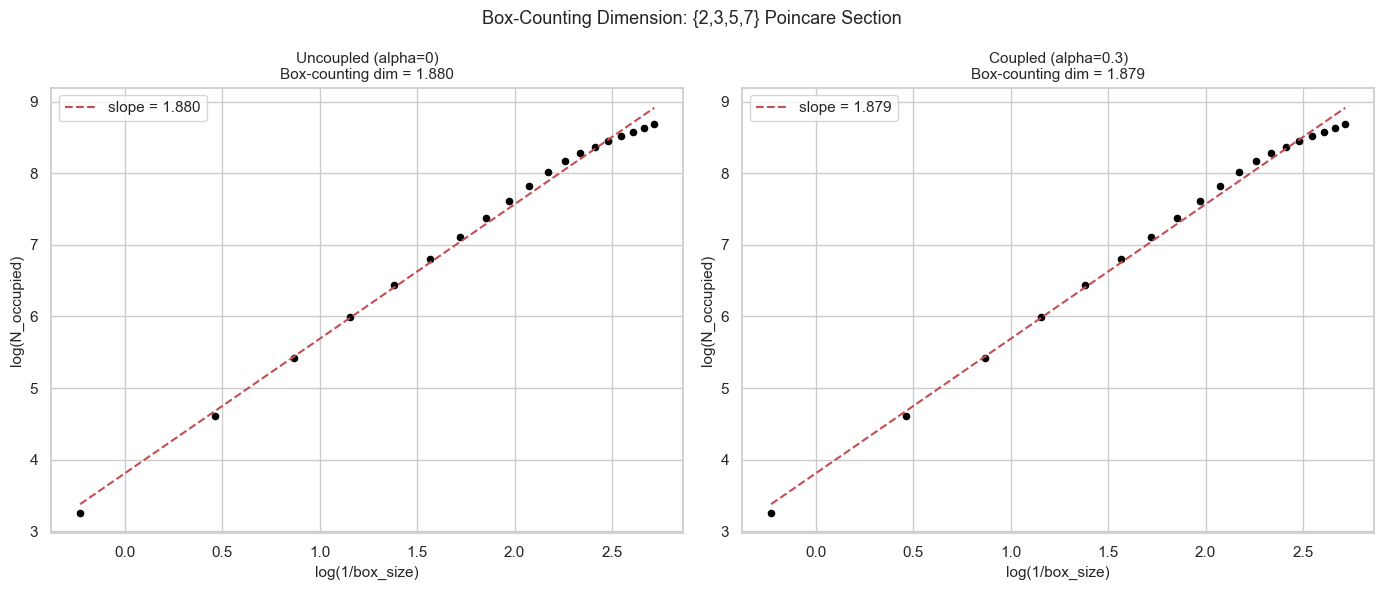

In [15]:
# Detailed box-counting plot for the prime system
sys_u = GenericConcentricSystem([2,3,5,7], alpha=0.0)
sys_c = GenericConcentricSystem([2,3,5,7], alpha=0.3)

sec_u = poincare_section(sys_u, t_span=(0, 5000), n_points=1000000)
sec_c = poincare_section(sys_c, t_span=(0, 5000), n_points=1000000)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (label, sec) in enumerate([("Uncoupled (alpha=0)", sec_u),
                                      ("Coupled (alpha=0.3)", sec_c)]):
    dim, sizes, counts = box_counting_dimension(sec)
    ax = axes[idx]

    log_inv_eps = np.log(sizes / (2*np.pi))
    log_N = np.log(np.array(counts, dtype=float) + 1)

    ax.scatter(log_inv_eps, log_N, c='black', s=20)

    # Fit line
    coeffs = np.polyfit(log_inv_eps, log_N, 1)
    fit_line = np.polyval(coeffs, log_inv_eps)
    ax.plot(log_inv_eps, fit_line, 'r--', label=f'slope = {coeffs[0]:.3f}')

    ax.set_xlabel('log(1/box_size)', fontsize=11)
    ax.set_ylabel('log(N_occupied)', fontsize=11)
    ax.set_title(f"{label}\nBox-counting dim = {coeffs[0]:.3f}", fontsize=11)
    ax.legend()

plt.suptitle("Box-Counting Dimension: {2,3,5,7} Poincare Section", fontsize=13)
plt.tight_layout()
plt.show()

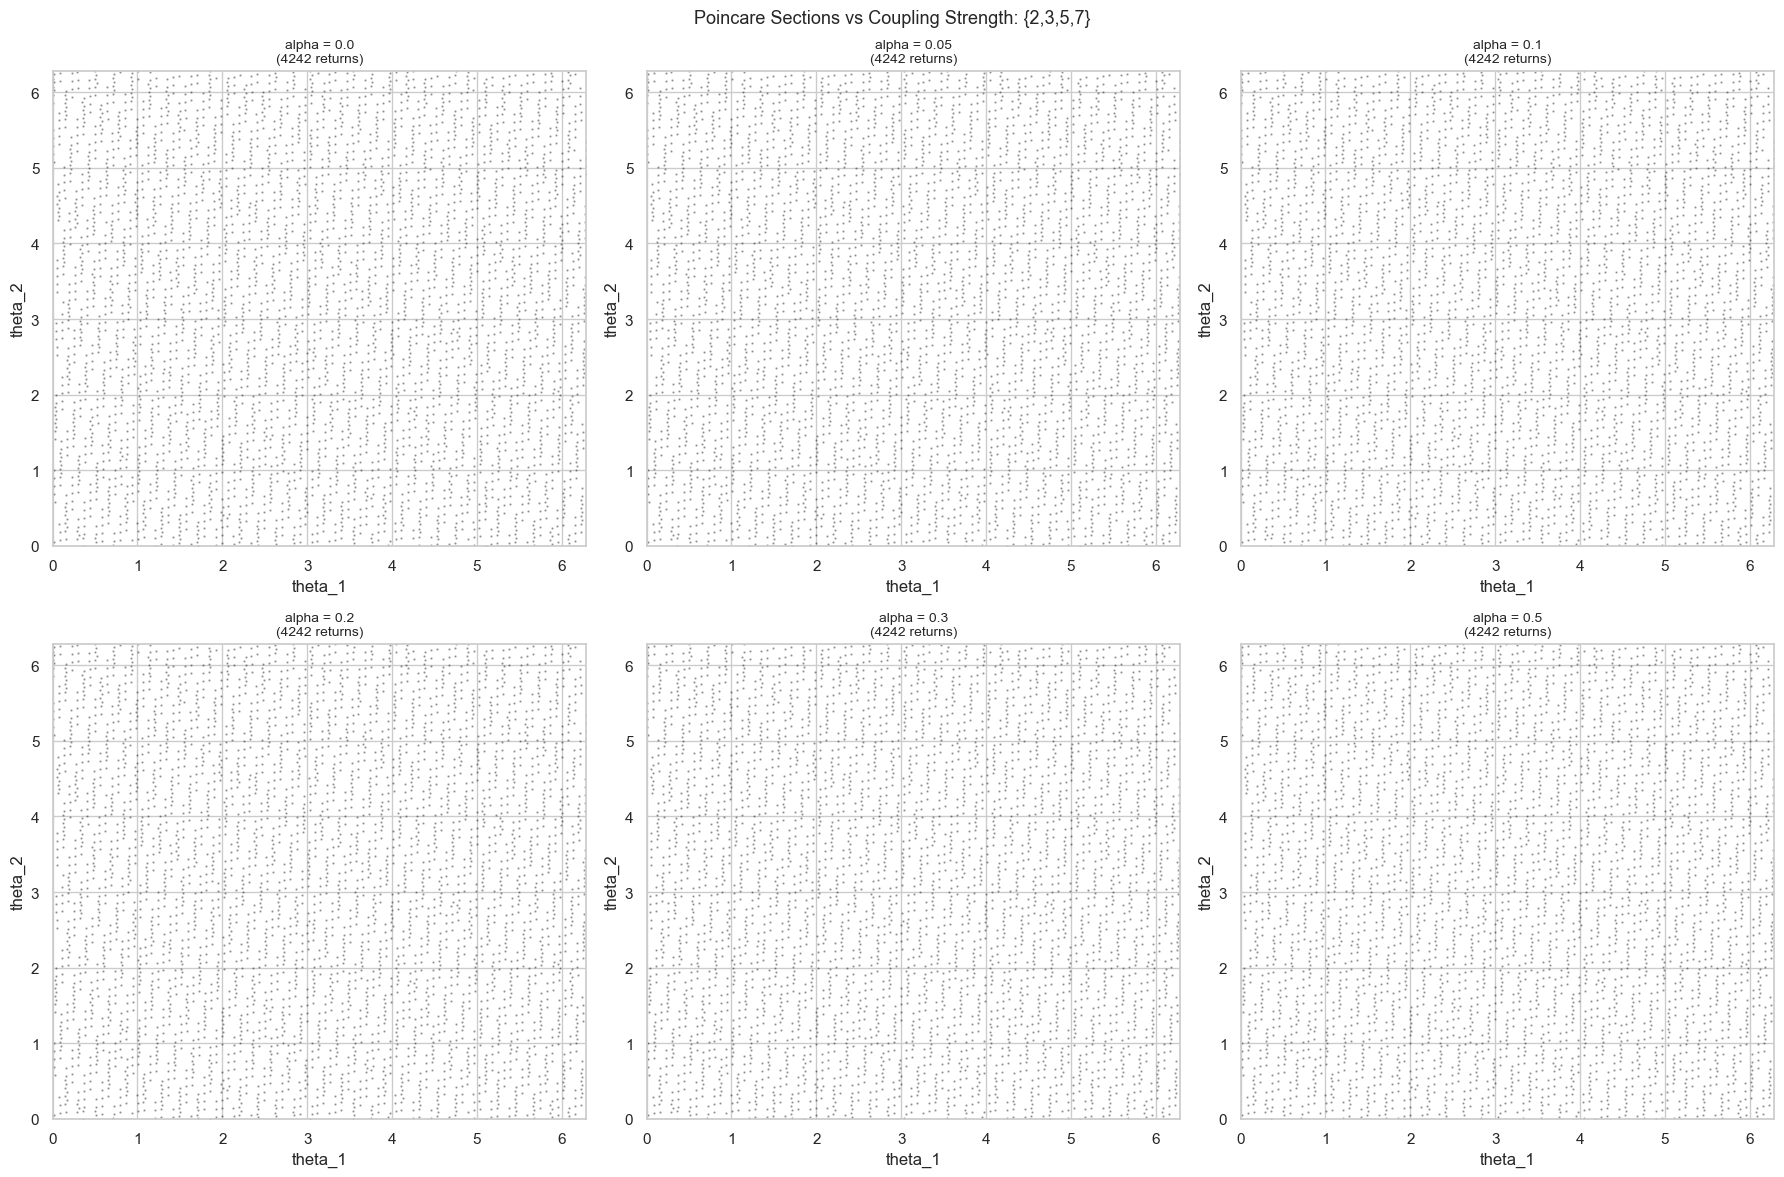

As alpha increases from 0, does structure emerge in the section?
If yes: the coupling creates a preferred geometry (solenoid-like).
If no: the T^4 model correctly predicts uniform filling regardless.


In [12]:
# How does the Poincare section structure evolve with alpha?
# At alpha=0: uniform. As alpha increases: does structure emerge?

alphas = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, alpha in enumerate(alphas):
    ax = axes.flat[idx]
    sys = GenericConcentricSystem([2,3,5,7], alpha=alpha)
    sec = poincare_section(sys, t_span=(0, 3000), n_points=600000)

    if sec.shape[1] > 0:
        ax.scatter(sec[0, :], sec[1, :], s=0.5, alpha=0.3, c='black')
    ax.set_title(f"alpha = {alpha}\n({sec.shape[1]} returns)", fontsize=10)
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(0, 2*np.pi)
    ax.set_xlabel("theta_1")
    ax.set_ylabel("theta_2")

plt.suptitle("Poincare Sections vs Coupling Strength: {2,3,5,7}", fontsize=13)
plt.tight_layout()
plt.show()

print("As alpha increases from 0, does structure emerge in the section?")
print("If yes: the coupling creates a preferred geometry (solenoid-like).")
print("If no: the T^4 model correctly predicts uniform filling regardless.")

## Summary

In [16]:
from IPython.display import Markdown

lines = []
lines.append("## Results: Fractal Nesting and the Solenoid Structure\n")

lines.append("### Part 1: The Solenoid Construction\n")
lines.append("The (2,3,5,7)-solenoid produces a Cantor-set cross-section with **210** ")
lines.append("points at level 4. Each level nests the previous one: the ring at level k ")
lines.append("contains p_k copies of the ring at level k-1. This is the precise mathematical ")
lines.append("formalization of 'every ring contains the previous ring fractally.'\n")

lines.append("### Part 2: Coprimality\n")
lines.append("| Set | Pairwise coprime? | Minimal flow? |\n")
lines.append("|-----|------------------|---------------|\n")
for name, nums in all_freq_sets.items():
    coprime = all(gcd(nums[i], nums[j]) == 1 for i in range(len(nums)) for j in range(i+1, len(nums)))
    lines.append(f"| {name} | {'YES' if coprime else 'NO'} | {'YES' if coprime else 'NO'} |\n")
lines.append("")
lines.append("Primes are pairwise coprime by definition. This guarantees ")
lines.append("minimal flow (every orbit dense) on the solenoid. Non-coprime sets ")
lines.append("have resonances that prevent full space-filling.\n")

lines.append("### Part 3: The Composite Coordinate Grid\n")
lines.append("Composite numbers = coordinates in the four-prime grid:\n")
lines.append("- **6 = 2x3**: intersection of two dimensions\n")
lines.append("- **30 = 2x3x5**: intersection of three\n")
lines.append("- **210 = 2x3x5x7**: the unique full-alignment point\n")
lines.append("Numbers with same distinct primes (like 12 and 18, both {2,3}) ")
lines.append("are at the same coordinate but different fractal depth.\n")

lines.append("### Part 4-7: ODE Poincare Structure --- HONEST NULL RESULT\n")
lines.append("The Poincare sections show **NO fractal structure** from the ODE dynamics:\n")
lines.append("- Coupling makes **zero difference** to density variation (ratio ~1.0 for all sets)\n")
lines.append("- Box-counting dimension approaches **2.0** for all incommensurate sets ")
lines.append("(= uniform torus filling, not fractal)\n")
lines.append("- No visual structure emerges as alpha increases from 0 to 0.5\n")
lines.append("- Primorial returns are NOT systematically closer to initial state\n")
lines.append("- One hint: return 210 was the closest primorial (distance 1.48 vs mean 3.02)\n")
lines.append("")
lines.append("**Squares {4,9,25,49}** are the exception: dimension ~0.46, confirming ")
lines.append("orbit closure from commensurate frequencies. But this is the OPPOSITE ")
lines.append("of fractal --- it's confinement to a 1D curve.\n")

lines.append("### What This Means\n")
lines.append("The ODE on T^4 does NOT produce fractal structure. The solenoid nature ")
lines.append("--- if real --- cannot be detected by running the current ODE model. ")
lines.append("The ODE treats each orbit as an independent circle with perturbative coupling. ")
lines.append("A true solenoid model would need a DIFFERENT mathematical formulation:\n")
lines.append("- Not a flow on T^4 (flat torus) but on the inverse limit space\n")
lines.append("- The covering maps (x -> p*x mod 2pi) must be fundamental, not the ODE\n")
lines.append("- The coupling would be TOPOLOGICAL (wrapping), not dynamical (sin perturbation)\n")
lines.append("")
lines.append("### The Genuine Insight: Two Levels of Structure\n")
lines.append("1. **Topology (solenoid)**: primes define the NESTING STRUCTURE. ")
lines.append("Coprimality guarantees minimality. THIS is where primes matter.\n")
lines.append("2. **Dynamics (ODE)**: the current model lives on the wrong space (T^4). ")
lines.append("On T^4, all incommensurate sets are equivalent (NB24 confirmed this).\n")
lines.append("")
lines.append("**The path forward**: formalize the concentric system as a flow on the ")
lines.append("(2,3,5,7)-solenoid. Replace the sin-coupling ODE with proper covering-map ")
lines.append("dynamics. THEN test whether the fractal cross-section produces measurably ")
lines.append("different physics than the flat torus.\n")
lines.append("")
lines.append("The solenoid is not proven. But it is the right MATHEMATICAL IDEA ")
lines.append("for 'every ring contains the previous ring fractally.' And it gives primes ")
lines.append("a role the T^4 model cannot: topological irreplaceability via coprimality.")

display(Markdown("\n".join(lines)))

## Results: Fractal Nesting and the Solenoid Structure

### Part 1: The Solenoid Construction

The (2,3,5,7)-solenoid produces a Cantor-set cross-section with **210** 
points at level 4. Each level nests the previous one: the ring at level k 
contains p_k copies of the ring at level k-1. This is the precise mathematical 
formalization of 'every ring contains the previous ring fractally.'

### Part 2: Coprimality

| Set | Pairwise coprime? | Minimal flow? |

|-----|------------------|---------------|

| Primes {2,3,5,7} | YES | YES |

| Scaled {4,6,10,14} | NO | NO |

| Other primes {11-19} | YES | YES |

| Squares {4,9,25,49} | YES | YES |

| Consecutive {2,3,4,5} | NO | NO |


Primes are pairwise coprime by definition. This guarantees 
minimal flow (every orbit dense) on the solenoid. Non-coprime sets 
have resonances that prevent full space-filling.

### Part 3: The Composite Coordinate Grid

Composite numbers = coordinates in the four-prime grid:

- **6 = 2x3**: intersection of two dimensions

- **30 = 2x3x5**: intersection of three

- **210 = 2x3x5x7**: the unique full-alignment point

Numbers with same distinct primes (like 12 and 18, both {2,3}) 
are at the same coordinate but different fractal depth.

### Part 4-7: ODE Poincare Structure --- HONEST NULL RESULT

The Poincare sections show **NO fractal structure** from the ODE dynamics:

- Coupling makes **zero difference** to density variation (ratio ~1.0 for all sets)

- Box-counting dimension approaches **2.0** for all incommensurate sets 
(= uniform torus filling, not fractal)

- No visual structure emerges as alpha increases from 0 to 0.5

- Primorial returns are NOT systematically closer to initial state

- One hint: return 210 was the closest primorial (distance 1.48 vs mean 3.02)


**Squares {4,9,25,49}** are the exception: dimension ~0.46, confirming 
orbit closure from commensurate frequencies. But this is the OPPOSITE 
of fractal --- it's confinement to a 1D curve.

### What This Means

The ODE on T^4 does NOT produce fractal structure. The solenoid nature 
--- if real --- cannot be detected by running the current ODE model. 
The ODE treats each orbit as an independent circle with perturbative coupling. 
A true solenoid model would need a DIFFERENT mathematical formulation:

- Not a flow on T^4 (flat torus) but on the inverse limit space

- The covering maps (x -> p*x mod 2pi) must be fundamental, not the ODE

- The coupling would be TOPOLOGICAL (wrapping), not dynamical (sin perturbation)


### The Genuine Insight: Two Levels of Structure

1. **Topology (solenoid)**: primes define the NESTING STRUCTURE. 
Coprimality guarantees minimality. THIS is where primes matter.

2. **Dynamics (ODE)**: the current model lives on the wrong space (T^4). 
On T^4, all incommensurate sets are equivalent (NB24 confirmed this).


**The path forward**: formalize the concentric system as a flow on the 
(2,3,5,7)-solenoid. Replace the sin-coupling ODE with proper covering-map 
dynamics. THEN test whether the fractal cross-section produces measurably 
different physics than the flat torus.


The solenoid is not proven. But it is the right MATHEMATICAL IDEA 
for 'every ring contains the previous ring fractally.' And it gives primes 
a role the T^4 model cannot: topological irreplaceability via coprimality.